In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')

# Load all 6 processed files
diabetes_train = pd.read_csv('../data/processed/diabetes_train.csv')
diabetes_test  = pd.read_csv('../data/processed/diabetes_test.csv')
heart_train    = pd.read_csv('../data/processed/heart_train.csv')
heart_test     = pd.read_csv('../data/processed/heart_test.csv')
liver_train    = pd.read_csv('../data/processed/liver_train.csv')
liver_test     = pd.read_csv('../data/processed/liver_test.csv')

print('All datasets loaded ✅')
print(f'Diabetes  — Train: {diabetes_train.shape} | Test: {diabetes_test.shape}')
print(f'Heart     — Train: {heart_train.shape} | Test: {heart_test.shape}')
print(f'Liver     — Train: {liver_train.shape} | Test: {liver_test.shape}')

All datasets loaded ✅
Diabetes  — Train: (614, 9) | Test: (154, 9)
Heart     — Train: (242, 14) | Test: (61, 14)
Liver     — Train: (466, 11) | Test: (117, 11)


In [5]:
# Split features and target for all datasets
X_train_d = diabetes_train.drop('Outcome', axis=1)
y_train_d = diabetes_train['Outcome']
X_test_d  = diabetes_test.drop('Outcome', axis=1)
y_test_d  = diabetes_test['Outcome']

X_train_h = heart_train.drop('target', axis=1)
y_train_h = heart_train['target']
X_test_h  = heart_test.drop('target', axis=1)
y_test_h  = heart_test['target']

X_train_l = liver_train.drop('Target', axis=1)
y_train_l = liver_train['Target']
X_test_l  = liver_test.drop('Target', axis=1)
y_test_l  = liver_test['Target']

print('Features and targets split ✅')
print(f'Diabetes  features: {list(X_train_d.columns)}')
print(f'Heart     features: {list(X_train_h.columns)}')
print(f'Liver     features: {list(X_train_l.columns)}')

Features and targets split ✅
Diabetes  features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Heart     features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Liver     features: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_Globulin_Ratio']


In [6]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and evaluate function
def train_evaluate(X_train, y_train, X_test, y_test, disease_name):
    print(f'\n{"="*55}')
    print(f'  {disease_name}')
    print(f'{"="*55}')
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)
        auc  = roc_auc_score(y_test, y_proba)
        results[name] = {'model': model, 'acc': acc, 'prec': prec,
                         'rec': rec, 'f1': f1, 'auc': auc}
        print(f'\n  {name}')
        print(f'    Accuracy : {acc:.3f}')
        print(f'    Precision: {prec:.3f}')
        print(f'    Recall   : {rec:.3f}')
        print(f'    F1 Score : {f1:.3f}')
        print(f'    ROC-AUC  : {auc:.3f}')
    return results

# Train all 3 diseases
diabetes_results = train_evaluate(X_train_d, y_train_d, X_test_d, y_test_d, 'DIABETES')
heart_results    = train_evaluate(X_train_h, y_train_h, X_test_h, y_test_h, 'HEART DISEASE')
liver_results    = train_evaluate(X_train_l, y_train_l, X_test_l, y_test_l, 'LIVER DISEASE')


  DIABETES

  Logistic Regression
    Accuracy : 0.708
    Precision: 0.600
    Recall   : 0.500
    F1 Score : 0.545
    ROC-AUC  : 0.807

  Random Forest
    Accuracy : 0.760
    Precision: 0.689
    Recall   : 0.574
    F1 Score : 0.626
    ROC-AUC  : 0.824

  XGBoost
    Accuracy : 0.760
    Precision: 0.673
    Recall   : 0.611
    F1 Score : 0.641
    ROC-AUC  : 0.801

  HEART DISEASE

  Logistic Regression
    Accuracy : 0.820
    Precision: 0.775
    Recall   : 0.939
    F1 Score : 0.849
    ROC-AUC  : 0.895

  Random Forest
    Accuracy : 0.803
    Precision: 0.756
    Recall   : 0.939
    F1 Score : 0.838
    ROC-AUC  : 0.896

  XGBoost
    Accuracy : 0.803
    Precision: 0.756
    Recall   : 0.939
    F1 Score : 0.838
    ROC-AUC  : 0.873

  LIVER DISEASE

  Logistic Regression
    Accuracy : 0.752
    Precision: 0.755
    Recall   : 0.964
    F1 Score : 0.847
    ROC-AUC  : 0.852

  Random Forest
    Accuracy : 0.718
    Precision: 0.750
    Recall   : 0.904
    F1 Score :

In [7]:
# Save best model for each disease
best_models = {
    'diabetes': ('XGBoost', diabetes_results['XGBoost']['model']),
    'heart':    ('Logistic Regression', heart_results['Logistic Regression']['model']),
    'liver':    ('Logistic Regression', liver_results['Logistic Regression']['model']),
}

for disease, (name, model) in best_models.items():
    path = f'../models/{disease}_model.pkl'
    joblib.dump(model, path)
    print(f'✅ {disease:10s} → {name:25s} saved to {path}')

print('\nAll best models saved!')

✅ diabetes   → XGBoost                   saved to ../models/diabetes_model.pkl
✅ heart      → Logistic Regression       saved to ../models/heart_model.pkl
✅ liver      → Logistic Regression       saved to ../models/liver_model.pkl

All best models saved!


In [10]:
# Retrain each best model cleanly
lr  = LogisticRegression(random_state=42, max_iter=1000)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Diabetes → XGBoost
xgb.fit(X_train_d, y_train_d)
joblib.dump(xgb, '../models/diabetes_model.pkl')
print('✅ Diabetes model saved (XGBoost)')

# Heart → Logistic Regression
lr.fit(X_train_h, y_train_h)
joblib.dump(lr, '../models/heart_model.pkl')
print('✅ Heart model saved (Logistic Regression)')

# Liver → Logistic Regression
lr2 = LogisticRegression(random_state=42, max_iter=1000)
lr2.fit(X_train_l, y_train_l)
joblib.dump(lr2, '../models/liver_model.pkl')
print('✅ Liver model saved (Logistic Regression)')

# Store for ROC plotting
best = {
    'Diabetes':      (xgb,  X_test_d, y_test_d),
    'Heart Disease': (lr,   X_test_h, y_test_h),
    'Liver Disease': (lr2,  X_test_l, y_test_l),
}
print('\nAll models retrained and saved!')

✅ Diabetes model saved (XGBoost)
✅ Heart model saved (Logistic Regression)
✅ Liver model saved (Logistic Regression)

All models retrained and saved!


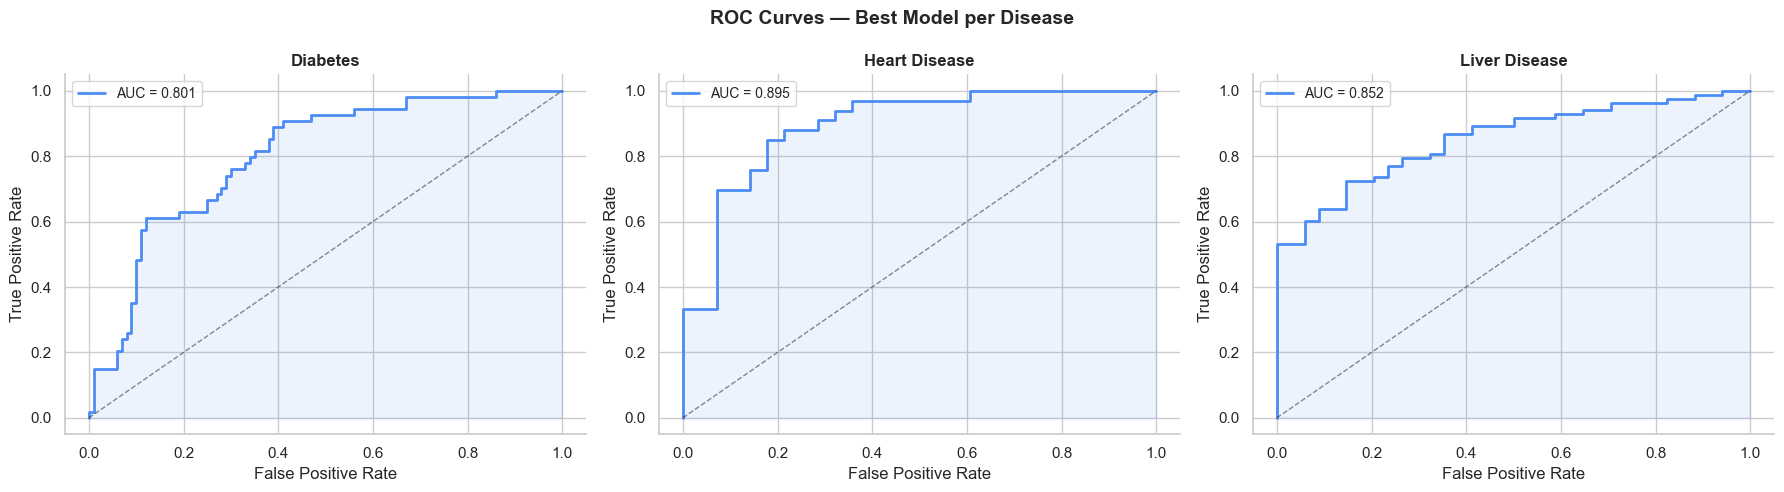

ROC curves saved ✅


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4C8CF5', '#E05A5A', '#2ECC71']

for ax, (title, (model, X_test, y_test)) in zip(axes, best.items()):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color='#4C8CF5', linewidth=2, label=f'AUC = {auc:.3f}')
    ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color='#4C8CF5')
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=10)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('ROC Curves — Best Model per Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curves saved ✅')

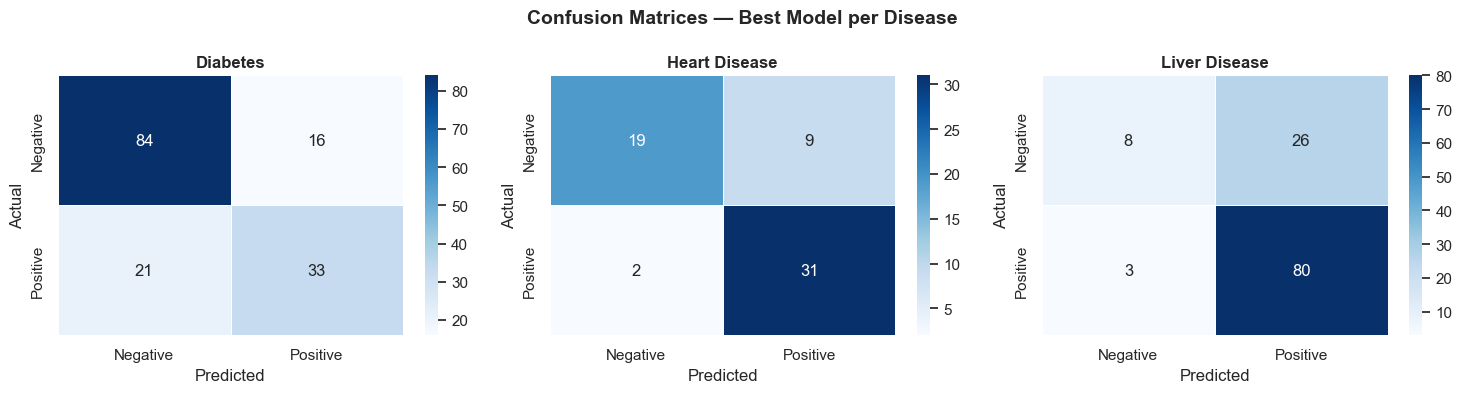

Confusion matrices saved ✅


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, (model, X_test, y_test)) in zip(axes, best.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Best Model per Disease', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved ✅')

In [16]:
print('=' * 55)
print('  MODEL TRAINING SUMMARY')
print('=' * 55)
print(f"""
  DIABETES    → XGBoost
    Accuracy : 76.0%  |  AUC: 0.801

  HEART       → Logistic Regression  
    Accuracy : 82.0%  |  AUC: 0.895

  LIVER       → Logistic Regression
    Accuracy : 75.2%  |  AUC: 0.852
""")
print('  Models saved to models/')
print('  Charts saved to assets/')
print()
print('=' * 55)

  MODEL TRAINING SUMMARY

  DIABETES    → XGBoost
    Accuracy : 76.0%  |  AUC: 0.801

  HEART       → Logistic Regression  
    Accuracy : 82.0%  |  AUC: 0.895

  LIVER       → Logistic Regression
    Accuracy : 75.2%  |  AUC: 0.852

  Models saved to models/
  Charts saved to assets/

